Classificazione GRID SERACH

In [2]:
import numpy as np
from sklearn.svm import SVC
import matplotlib.pylab as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV

Carico il dataset totale

In [3]:
data=load_iris()
X=data.data
y=data.target
feature_names=data.feature_names
target_names=data.target_names

Divido il dataset tra train e test (70%, 30%)

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,shuffle=True,random_state=42,test_size=0.3)

Standarizzazione del train ed applicazione anche al test

In [5]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
model_default=SVC(random_state=42)
model_default.fit(X_train_scaled,y_train)
y_pred_default=model_default.predict(X_test_scaled)

acc_defaul=accuracy_score(y_test,y_pred_default)

In [17]:
param_grid={'C':[0.1,1,10],'kernel':['linear','rbf'],'gamma':['scale','auto']} #dizionario param grid

grid_search= GridSearchCV(SVC(random_state=42),param_grid=param_grid,cv=5)
grid_search.fit(X_train_scaled,y_train)

best_model=grid_search.best_estimator_
y_pred_best=best_model.predict(X_test_scaled)
acc_best=accuracy_score(y_test,y_pred_best)

In [18]:
print(f"Migliori parametri;\n{grid_search.best_params_}")
print(f"Accuracy (default):\t{acc_defaul*100:.2f}%")
print(f"Accuracy (best):\t{acc_best*100:.2f}%")

Migliori parametri;
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (default):	93.33%
Accuracy (best):	91.11%


Le accuracy non sono migliorate, anzi leggermente migliore con l'estimatore di default, questo perchè il tunning dei parametri non garantisce sempre un miglioramento delle prestazioni, soprattutto quando si ha a che fare con dataset piccoli con classi già abbastanza separate, ed il modello di default va già bene senza ricorrere a parametri più complessi. Il gridSearch è più utile quando il modello ed il dataset sono più complessi.

scaling di tutto il dataset per il plot finale

riduzione dimensionale

In [ ]:
X_scaled=scaler.fit_transform(X)
X_pca=PCA(n_components=2).fit_transform(X_scaled)

#riaddestro i modelli con tutto il dataset scalato
model_default.fit(X_pca,y)
best_model.fit(X_pca,y)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [37]:
model_default_pca=SVC(random_state=42)
model_default_pca.fit(X_pca,y)

best_model_pca=SVC(**grid_search.best_params_,random_state=42)   # svc creato con i valori della grid search
best_model_pca.fit(X_pca,y)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


ora faccio i due plot, creo una funzione per evitare di fare la stessa operazione due volte

In [40]:
def plot_decision_boundary(ax, X, y, model, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")


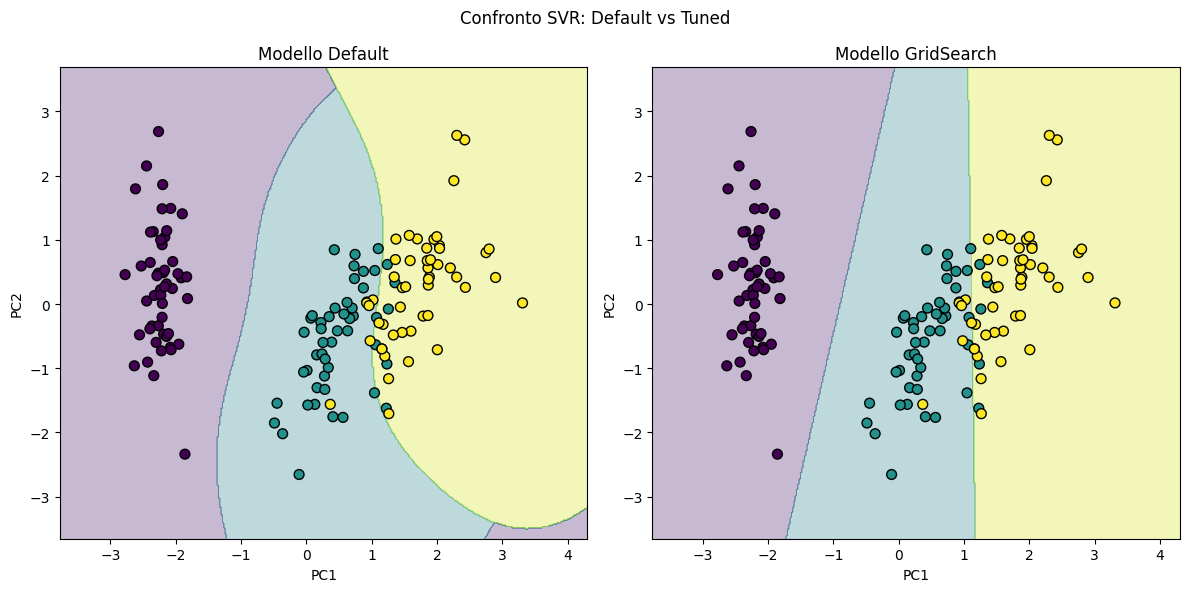

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_decision_boundary(axes[0], X_pca, y, model_default_pca, "Modello Default")
plot_decision_boundary(axes[1], X_pca, y, best_model_pca, "Modello GridSearch")
plt.suptitle("Confronto SVR: Default vs Tuned")
plt.tight_layout()
plt.show()